# Evaluation — HARNN Word2Vec + Global

Giữ lại các đánh giá cơ bản cho phân loại đa lớp.

| Cell | Nội dung |
|------|----------|
| 1 | Load model + test set + dự đoán |
| 2 | Ma trận nhầm lẫn (Confusion Matrix) L1 |
| 3 | Accuracy, Precision, Recall, F1 (Macro/Micro) |


## Cell 1 — Load model & test set


In [2]:
import json, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score,
)

# ── Paths ────────────────────────────────────────────────────────────────
DATA_DIR   = Path(r'C:\Users\Admin\Documents\nlp\NLP_Project\data\process_data')
OUTPUT_DIR = Path(r'C:\Users\Admin\Documents\nlp\NLP_Project\output')
CKPT_PATH  = OUTPUT_DIR / 'models' / 'checkpoints' / 'best_model.pt'
FIG_DIR    = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED       = 42
MAX_LEN    = 512
BATCH_SIZE = 64
EMBED_DIM  = 100
HIDDEN     = 256

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load data ────────────────────────────────────────────────────────────
with open(DATA_DIR / 'dataset.json',   encoding='utf-8') as f: articles  = json.load(f)
with open(DATA_DIR / 'vocab.json',     encoding='utf-8') as f: vocab     = json.load(f)
with open(DATA_DIR / 'label_map.json', encoding='utf-8') as f: label_map = json.load(f)

VOCAB_SIZE  = len(vocab)
NUM_CLASSES = [len(label_map['l1']), len(label_map['l2']), len(label_map['l3'])]

# idx → tên nhãn
IDX2LABEL = {lv: {v: k for k, v in label_map[lv].items()} for lv in ['l1', 'l2', 'l3']}

# ── Dataset ───────────────────────────────────────────────────────────────
class VnExpressDataset(Dataset):
    def __init__(self, articles, vocab, max_len=MAX_LEN):
        self.articles, self.vocab, self.max_len = articles, vocab, max_len
    def __len__(self): return len(self.articles)
    def __getitem__(self, idx):
        a   = self.articles[idx]
        ids = [self.vocab.get(t, 1) for t in a['tokens']][:self.max_len]
        ids += [0] * (self.max_len - len(ids))
        return (
            torch.tensor(ids,         dtype=torch.long),
            torch.tensor(a['vec_l1'], dtype=torch.float),
            torch.tensor(a['vec_l2'], dtype=torch.float),
            torch.tensor(a['vec_l3'], dtype=torch.float),
        )

dataset = VnExpressDataset(articles, vocab)
n       = len(dataset)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)
n_test  = n - n_train - n_val

gen = torch.Generator().manual_seed(SEED)
_, _, test_set = random_split(dataset, [n_train, n_val, n_test], generator=gen)
test_loader    = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test set: {len(test_set)} bài')

# ── Model ─────────────────────────────────────────────────────────────────
class HARNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes_per_level, dropout=0.5):
        super().__init__()
        self.num_levels  = len(num_classes_per_level)
        self.hidden_size = hidden_size
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bigru       = nn.GRU(embed_dim, hidden_size, bidirectional=True, batch_first=True)
        self.dropout     = nn.Dropout(dropout)
        self.attention   = nn.ModuleList([nn.Linear(hidden_size * 2, 1) for _ in range(self.num_levels)])
        self.ham         = nn.LSTMCell(hidden_size * 2, hidden_size)
        self.classifiers = nn.ModuleList([nn.Linear(hidden_size * 3, n) for n in num_classes_per_level])
    def forward(self, x):
        B      = x.size(0)
        doc, _ = self.bigru(self.dropout(self.embedding(x)))
        doc    = self.dropout(doc)
        h = torch.zeros(B, self.hidden_size, device=x.device)
        c = torch.zeros(B, self.hidden_size, device=x.device)
        preds = []
        for lv in range(self.num_levels):
            context = (torch.softmax(self.attention[lv](doc), dim=1) * doc).sum(dim=1)
            h, c    = self.ham(context, (h, c))
            preds.append(torch.sigmoid(self.classifiers[lv](self.dropout(torch.cat([context, h], dim=-1)))))
        return preds

model = HARNN(VOCAB_SIZE, EMBED_DIM, HIDDEN, NUM_CLASSES).to(device)
ckpt  = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Checkpoint: epoch {ckpt['epoch']}  val F1-L1={ckpt['val_f1_l1']:.3f}")

# ── Collect predictions ───────────────────────────────────────────────────
@torch.no_grad()
def get_preds_labels():
    probs_per_level  = [[] for _ in range(3)]
    labels_per_level = [[] for _ in range(3)]
    for ids, l1, l2, l3 in test_loader:
        out = model(ids.to(device))
        for i, lbl in enumerate([l1, l2, l3]):
            probs_per_level[i].append(out[i].cpu().numpy())
            labels_per_level[i].append(lbl.numpy())
    probs = [np.concatenate(p) for p in probs_per_level]
    labels = [np.concatenate(l) for l in labels_per_level]
    return probs, labels

probs, labels = get_preds_labels()

# Đa lớp: dùng argmax để lấy nhãn dự đoán / nhãn thực
true_class = [np.argmax(labels[i], axis=1) for i in range(3)]
pred_class = [np.argmax(probs[i],  axis=1) for i in range(3)]

print(f'Predictions collected: {len(true_class[0])} bài')

Test set: 1180 bài
Checkpoint: epoch 7  val F1-L1=0.881
Predictions collected: 1180 bài


## Cell 2 — Confusion Matrix L1
Thấy domain nào hay bị nhầm sang domain nào.


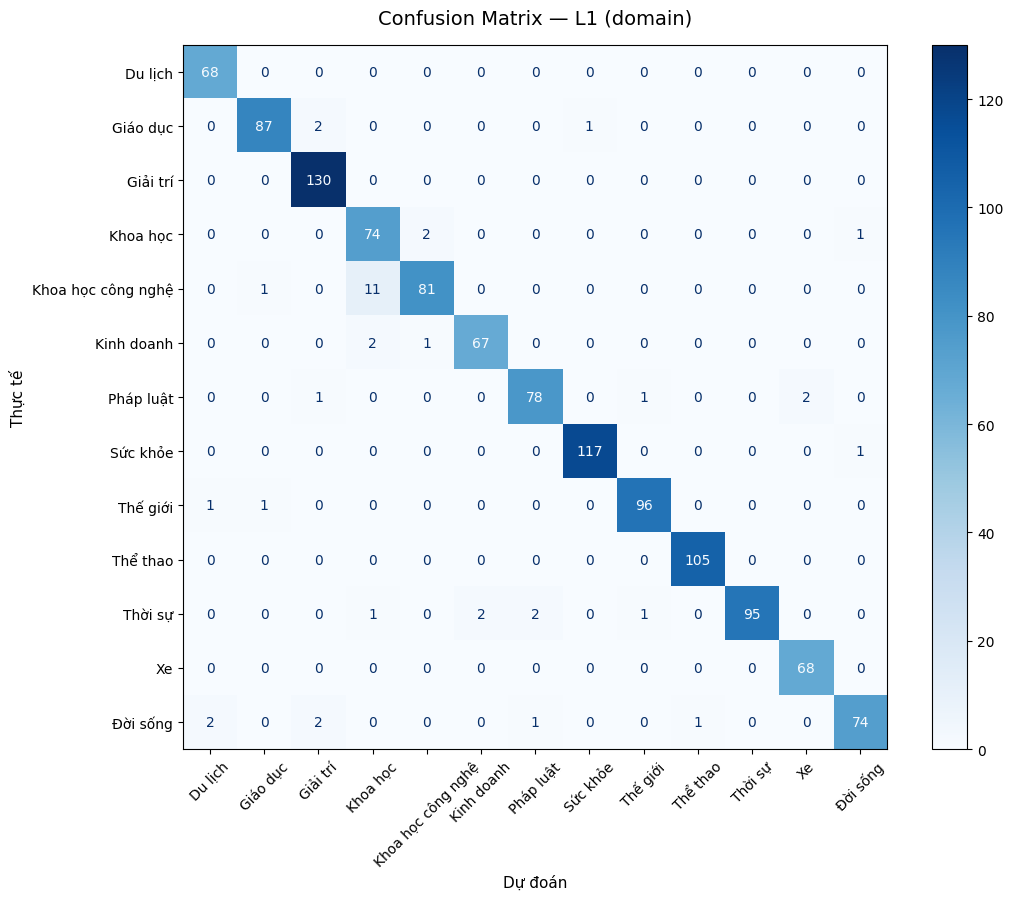


Top nhầm lẫn L1:
  Khoa học công nghệ → Khoa học         11 bài
  Đời sống        → Giải trí         2 bài
  Đời sống        → Du lịch          2 bài
  Thời sự         → Pháp luật        2 bài
  Thời sự         → Kinh doanh       2 bài
  Pháp luật       → Xe               2 bài
  Kinh doanh      → Khoa học         2 bài
  Khoa học        → Khoa học công nghệ  2 bài


In [3]:
# Confusion Matrix cho L1
true_l1 = true_class[0]
pred_l1 = pred_class[0]

label_names = [IDX2LABEL['l1'][i] for i in range(NUM_CLASSES[0])]
cm = confusion_matrix(true_l1, pred_l1)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)

ax.set_title('Confusion Matrix — L1 (domain)', fontsize=14, pad=15)
ax.set_xlabel('Dự đoán', fontsize=11)
ax.set_ylabel('Thực tế', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix_l1.png', dpi=150)
plt.show()

# In các cặp nhầm lẫn nhiều nhất
print('\nTop nhầm lẫn L1:')
errors = [(cm[i, j], label_names[i], label_names[j])
          for i in range(len(label_names))
          for j in range(len(label_names)) if i != j and cm[i, j] > 0]
for cnt, true, pred in sorted(errors, reverse=True)[:8]:
    print(f'  {true:<15} → {pred:<15}  {cnt} bài')

## Cell 3 — Accuracy, Precision, Recall, F1 (Macro/Micro)


EVALUATION:
----------------------------------------------------------------------------------------------------------------------
Level       Accuracy   Precision_micro   Recall_micro    F1_micro   Precision_macro   Recall_macro    F1_macro
----------------------------------------------------------------------------------------------------------------------
L1             0.966             0.966          0.966       0.966             0.965          0.965       0.964
L2             0.651             0.651          0.651       0.651             0.612          0.688       0.607
L3             0.179             0.179          0.179       0.179             0.334          0.762       0.403
----------------------------------------------------------------------------------------------------------------------


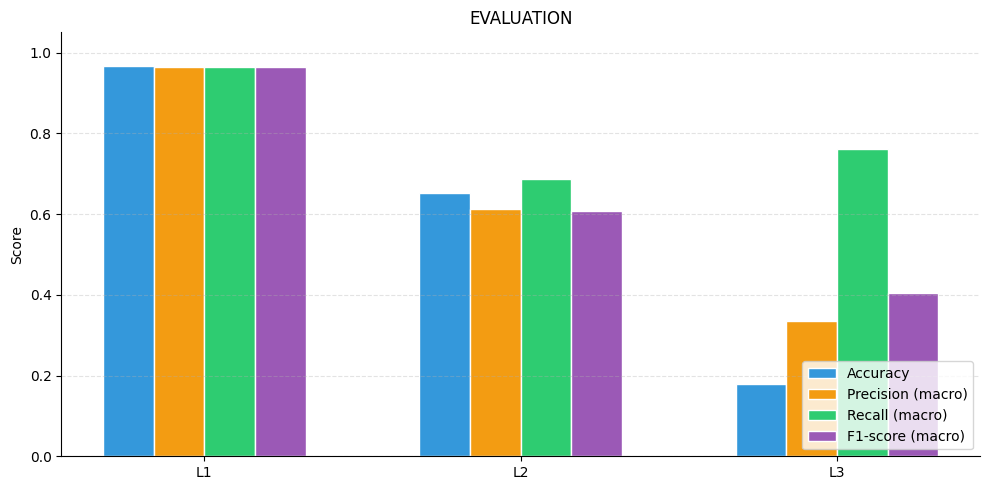

In [4]:
levels = ['L1', 'L2', 'L3']
metrics_rows = []

for i, lv in enumerate(levels):
    y_true = true_class[i]
    y_pred = pred_class[i]

    row = {
        'Level': lv,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'F1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    metrics_rows.append(row)

print('EVALUATION:')
print('-' * 118)
print(
    f"{'Level':<8} {'Accuracy':>11} {'Precision_micro':>17} {'Recall_micro':>14} {'F1_micro':>11} "
    f"{'Precision_macro':>17} {'Recall_macro':>14} {'F1_macro':>11}"
)
print('-' * 118)
for r in metrics_rows:
    print(
        f"{r['Level']:<8} "
        f"{r['Accuracy']:>11.3f} "
        f"{r['Precision_micro']:>17.3f} "
        f"{r['Recall_micro']:>14.3f} "
        f"{r['F1_micro']:>11.3f} "
        f"{r['Precision_macro']:>17.3f} "
        f"{r['Recall_macro']:>14.3f} "
        f"{r['F1_macro']:>11.3f}"
    )
print('-' * 118)

# Biểu đồ cơ bản: Accuracy, Precision, Recall, F1 (macro)
x = np.arange(len(levels))
width = 0.16

acc = [r['Accuracy'] for r in metrics_rows]
pre = [r['Precision_macro'] for r in metrics_rows]
rec = [r['Recall_macro'] for r in metrics_rows]
f1m = [r['F1_macro'] for r in metrics_rows]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5 * width, acc, width, label='Accuracy', color='#3498db', edgecolor='white', linewidth=1)
ax.bar(x - 0.5 * width, pre, width, label='Precision (macro)', color='#f39c12', edgecolor='white', linewidth=1)
ax.bar(x + 0.5 * width, rec, width, label='Recall (macro)', color='#2ecc71', edgecolor='white', linewidth=1)
ax.bar(x + 1.5 * width, f1m, width, label='F1-score (macro)', color='#9b59b6', edgecolor='white', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('EVALUATION')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'basic_metrics_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()